In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("ushape.csv")

In [5]:
df.head()


,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


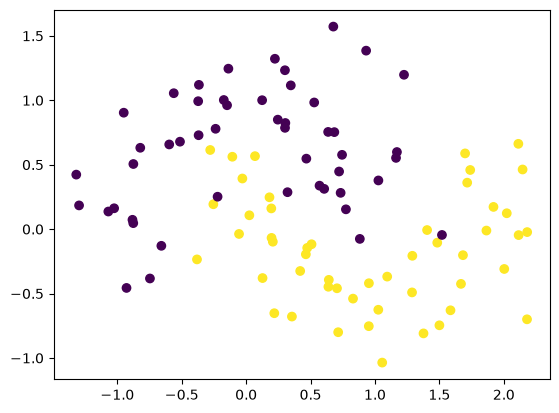

In [7]:
plt.scatter(
    x=df['3.159499363321345566e-02'],
    y=df['9.869877579082642072e-01'],
    c=df['0.000000000000000000e+00']
)
plt.show()

In [8]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [10]:
model = Sequential()

model.add(Dense(2,activation='tanh',input_dim=2))
model.add(Dense(2,activation='tanh'))
model.add(Dense(2,activation='tanh'))
model.add(Dense(2,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.get_weights()

[array([[-0.37665623,  0.27735925],
        [-1.0672814 , -0.5854312 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.40380275,  0.20048356],
        [-0.45093042, -0.15905428]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.3745197 , 0.87299335],
        [0.7075981 , 1.1854945 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.99154514, -0.28898817],
        [ 0.45007634,  0.11183262]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.3699335 ],
        [-0.03024352]], dtype=float32),
 array([0.], dtype=float32)]

In [15]:
initial_weights = model.get_weights()

In [16]:
initial_weights

[array([[-0.37665623,  0.27735925],
        [-1.0672814 , -0.5854312 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.40380275,  0.20048356],
        [-0.45093042, -0.15905428]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.3745197 , 0.87299335],
        [0.7075981 , 1.1854945 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.99154514, -0.28898817],
        [ 0.45007634,  0.11183262]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.3699335 ],
        [-0.03024352]], dtype=float32),
 array([0.], dtype=float32)]

In [17]:
initial_weights[0] = np.random.randn(
    model.get_weights()[0].shape[0],
    model.get_weights()[0].shape[1]
) * 0.01
initial_weights[1] = np.zeros(model.get_weights()[1].shape)

initial_weights[2] = np.random.randn(
    model.get_weights()[2].shape[0],
    model.get_weights()[2].shape[1]
) * 0.01
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

initial_weights[4] = np.random.randn(
    model.get_weights()[4].shape[0],
    model.get_weights()[4].shape[1]
) * 0.01
initial_weights[5] = np.zeros(model.get_weights()[5].shape)

initial_weights[6] = np.random.randn(
    model.get_weights()[6].shape[0],
    model.get_weights()[6].shape[1]
) * 0.01
initial_weights[7] = np.zeros(model.get_weights()[7].shape)

initial_weights[8] = np.random.randn(
    model.get_weights()[8].shape[0],
    model.get_weights()[8].shape[1]
) * 0.01
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [18]:
model.set_weights(initial_weights)

In [19]:
model.get_weights()



[array([[-0.01744902,  0.0129914 ],
        [-0.01996962,  0.0056046 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.02128566, -0.00247369],
        [-0.00663996, -0.00202173]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.00648555, -0.00561297],
        [-0.00100242, -0.00280489]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.01673794, -0.01695582],
        [ 0.02132434,  0.00574724]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.00061688],
        [ 0.00712105]], dtype=float32),
 array([0.], dtype=float32)]

In [20]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4810 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5063 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss:

In [23]:
model.get_weights()

[array([[ 0.07711908,  0.08828722],
        [-0.1157188 , -0.0709852 ]], dtype=float32),
 array([-0.00334926, -0.00320126], dtype=float32),
 array([[-0.11681252, -0.06806453],
        [-0.09290494, -0.05948146]], dtype=float32),
 array([-0.00292272,  0.00085461], dtype=float32),
 array([[ 0.08063532, -0.08963479],
        [ 0.05058075, -0.05243342]], dtype=float32),
 array([-0.02047822,  0.02048073], dtype=float32),
 array([[-0.03397209, -0.03302858],
        [ 0.03874046,  0.02277182]], dtype=float32),
 array([0.02464301, 0.02251305], dtype=float32),
 array([[0.02471929],
        [0.02684567]], dtype=float32),
 array([0.02060004], dtype=float32)]

<Axes: >

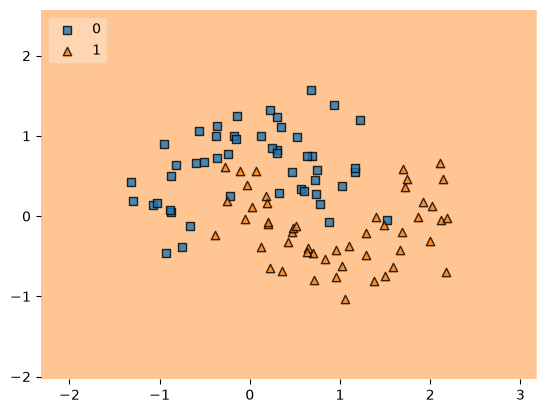

In [27]:
from mlxtend.plotting import plot_decision_regions

class KerasWrapper:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(X, verbose=0)
        return (pred > 0.5).astype(int).ravel()
    
wrapped_model = KerasWrapper(model)

plot_decision_regions(
    X,
    y.astype('int'),
    clf=wrapped_model,
    legend=2
)